In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")

# Load datasets
import os
os.chdir(r'c:\Users\kanis\ecommerce-analysis')  # set root as working directory

orders     = pd.read_csv('data/olist_orders_dataset.csv')
items      = pd.read_csv('data/olist_order_items_dataset.csv')
customers  = pd.read_csv('data/olist_customers_dataset.csv')
payments   = pd.read_csv('data/olist_order_payments_dataset.csv')
products   = pd.read_csv('data/olist_products_dataset.csv')

In [9]:
# Parse dates
date_cols = ['order_purchase_timestamp','order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Keep only delivered orders
orders = orders[orders['order_status'] == 'delivered'].copy()

# Delivery time in days
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

# Merge pipeline
df = (orders
      .merge(items[['order_id','product_id','price','freight_value']], on='order_id')
      .merge(customers[['customer_id','customer_state']], on='customer_id')
      .merge(payments[['order_id','payment_value']].drop_duplicates('order_id'), on='order_id'))

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
print(f"Shape: {df.shape}")
df.head()

Shape: (110194, 15)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,product_id,price,freight_value,customer_state,payment_value,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,87285b34884572647811a353c7ac498a,29.99,8.72,SP,18.12,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,BA,141.46,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,aa4383b373c6aca5d8797843e5594415,159.90,19.22,GO,179.12,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,RN,72.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,SP,28.62,2018-02


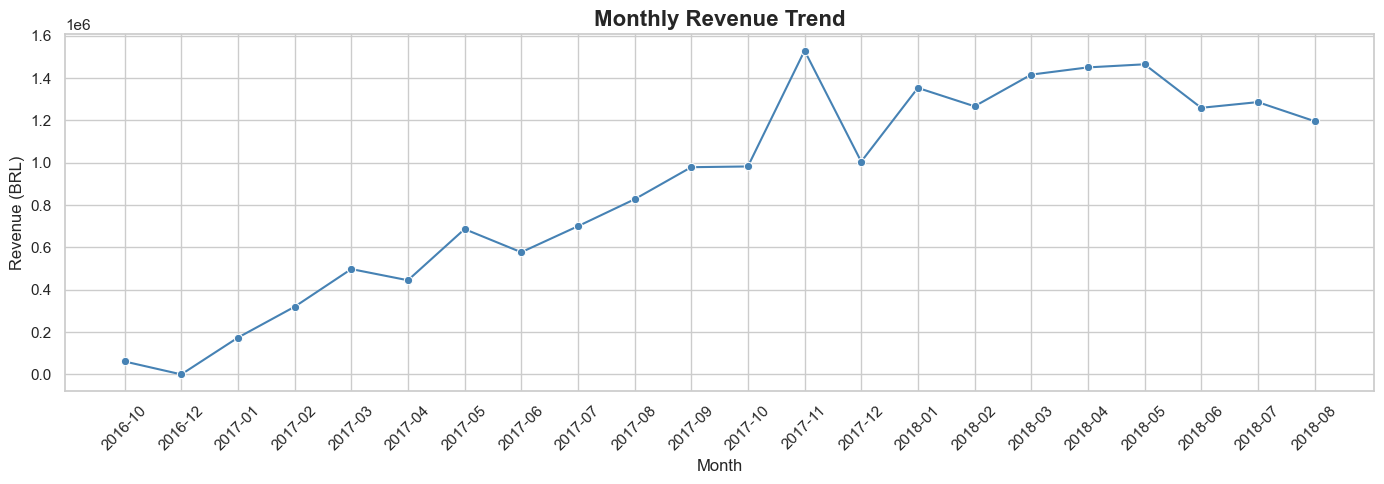

In [10]:
monthly = df.groupby('order_month')['payment_value'].sum().reset_index()
monthly['order_month'] = monthly['order_month'].astype(str)

plt.figure(figsize=(14,5))
sns.lineplot(data=monthly, x='order_month', y='payment_value', marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month'); plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.savefig('visuals/monthly_revenue.png', dpi=150)
plt.show()

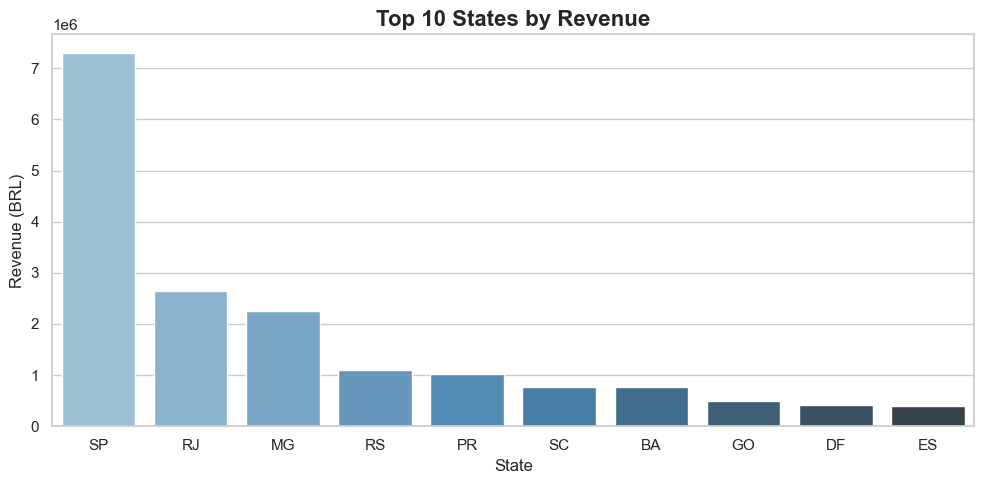

In [11]:
state_rev = df.groupby('customer_state')['payment_value'].sum().nlargest(10)

plt.figure(figsize=(10,5))
sns.barplot(x=state_rev.index, y=state_rev.values, palette='Blues_d')
plt.title('Top 10 States by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('State'); plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.savefig('visuals/top_states.png', dpi=150)
plt.show()

In [12]:
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id',                 'nunique'),
    Monetary  = ('payment_value',            'sum')
).reset_index()

print(rfm.describe().round(2))
rfm.head()

        Recency  Frequency   Monetary
count  96477.00    96477.0   96477.00
mean     240.12        1.0     201.88
std      152.83        0.0     619.16
min        1.00        1.0       0.01
25%      116.00        1.0      60.95
50%      221.00        1.0     107.46
75%      350.00        1.0     193.61
max      696.00        1.0  109312.64


,customer_id,Recency,Frequency,Monetary
0,00012a2ce6f8dcda20d059ce98491703,288,1,114.74
1,000161a058600d5901f007fab4c27140,410,1,67.41
2,0001fd6190edaaf884bcaf3d49edf079,548,1,195.42
3,0002414f95344307404f0ace7a26f1d5,379,1,179.35
4,000379cdec625522490c315e70c7a9fb,150,1,107.01


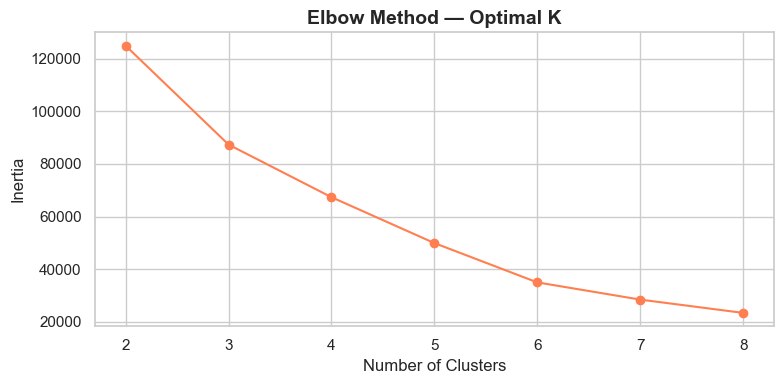


Silhouette Score: 0.525


In [14]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

# Elbow method
inertia = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, marker='o', color='coral')
plt.title('Elbow Method — Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters'); plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('visuals/elbow.png', dpi=150)
plt.show()

# Fit with k=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Segment'] = km.fit_predict(rfm_scaled)
print(f"\nSilhouette Score: {silhouette_score(rfm_scaled, rfm['Segment']):.3f}")

         Recency  Frequency  Monetary
Segment                              
0          388.2        1.0     191.8
1          129.1        1.0     192.4
2          334.0        1.0  109312.6
3          223.2        1.0   12457.8


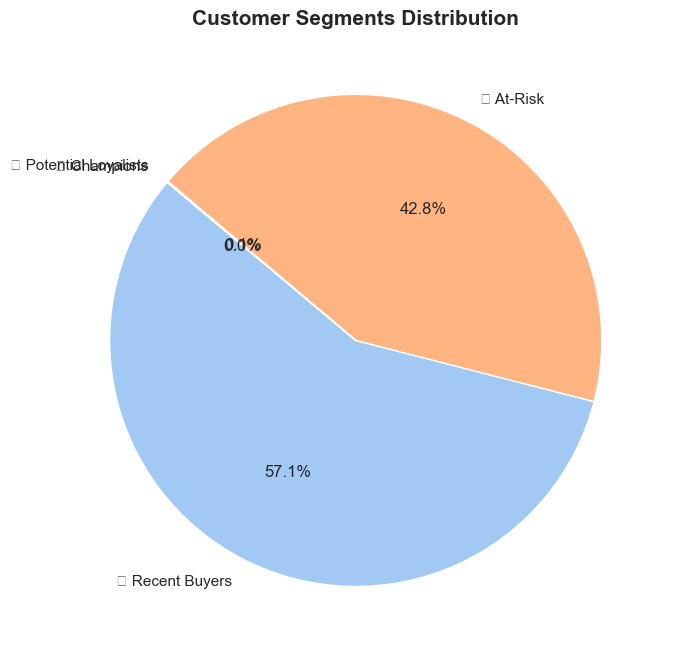

In [15]:
seg_summary = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)
print(seg_summary)

# Label segments based on profile (adjust if your clusters differ)
label_map = {
    rfm.groupby('Segment')['Monetary'].mean().idxmax(): '💎 Champions',
    rfm.groupby('Segment')['Recency'].mean().idxmin():  '🔄 Recent Buyers',
    rfm.groupby('Segment')['Frequency'].mean().idxmin(): '😴 At-Risk',
}
rfm['Segment_Label'] = rfm['Segment'].map(label_map).fillna('🌱 Potential Loyalists')

seg_counts = rfm['Segment_Label'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=140)
plt.title('Customer Segments Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/segments_pie.png', dpi=150)
plt.show()

In [16]:
total_revenue = df['payment_value'].sum()
avg_delivery  = df['delivery_days'].mean()
top_state     = df.groupby('customer_state')['payment_value'].sum().idxmax()

print("=" * 45)
print("        PROJECT SUMMARY")
print("=" * 45)
print(f"  Total Revenue Analyzed : R$ {total_revenue:,.0f}")
print(f"  Total Orders            : {df['order_id'].nunique():,}")
print(f"  Avg Delivery Time       : {avg_delivery:.1f} days")
print(f"  Top Revenue State       : {top_state}")
print(f"  Customer Segments Found : 4")
print(f"  Silhouette Score        : see above")
print("=" * 45)

        PROJECT SUMMARY
  Total Revenue Analyzed : R$ 19,476,572
  Total Orders            : 96,477
  Avg Delivery Time       : 12.0 days
  Top Revenue State       : SP
  Customer Segments Found : 4
  Silhouette Score        : see above
